In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import pandas as pd
url = '../datasets/nhanes_2015_2016.csv'
da = pd.read_csv(url)

# Studying Disrete Values

In [3]:
gender = da['RIAGENDR'] 
gender.value_counts() #tells how much have gender '1'==male and how much have gender '2'==female.

RIAGENDR
2    2976
1    2759
Name: count, dtype: int64

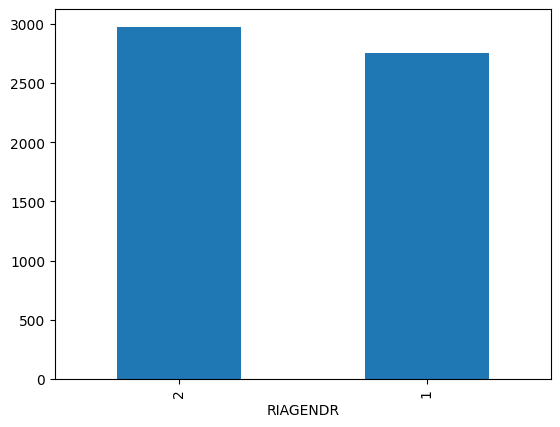

In [4]:
gender.value_counts().plot(kind = 'bar') #bar graph plot
plt.show()

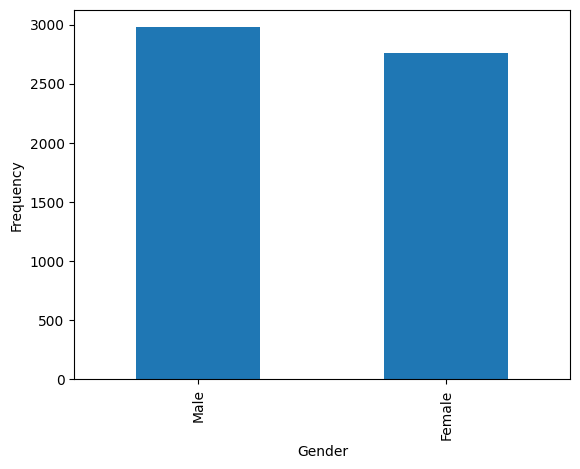

In [5]:
gender.value_counts().plot(kind='bar')
plt.xticks([0,1] , ['Male','Female']) #xticks function is to represent [0,1] as male and female in bar graph.The `0th` element in this array is 1 and `1st` element in array is 2. 

plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()

# Most Common Values (Mode)

In [6]:
sizes = np.array([22,23,32,32,39,42,42,42,42,42,42,42,43,51,51,55,54])

In [7]:
sizes.mean()

np.float64(40.94117647058823)

In [8]:
from collections import Counter
cnt = Counter()

for size in sizes:
    cnt[size]+=1

cnt.most_common()

[(np.int64(42), 7),
 (np.int64(32), 2),
 (np.int64(51), 2),
 (np.int64(22), 1),
 (np.int64(23), 1),
 (np.int64(39), 1),
 (np.int64(43), 1),
 (np.int64(55), 1),
 (np.int64(54), 1)]

In [9]:
cnt.most_common()[0] #gives the top most common value.

(np.int64(42), 7)

### Alternatively we can use scipy library

In [10]:
from scipy import stats

In [11]:
stats.mode(sizes)[0] #index 0 has value , index 1 has count

np.int64(42)

In [12]:
gender.mode() #using pandas

0    2
Name: RIAGENDR, dtype: int64

In [13]:
stats.mode(sizes)[0] #using scipy

np.int64(42)

# More than one Classes

In [14]:
da['HIQ210'].unique()

array([ 2., nan,  1.,  9.])

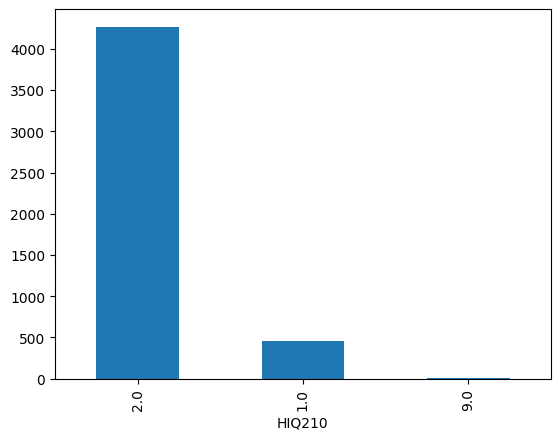

In [15]:
da['HIQ210'].value_counts().plot(kind='bar')
plt.show()

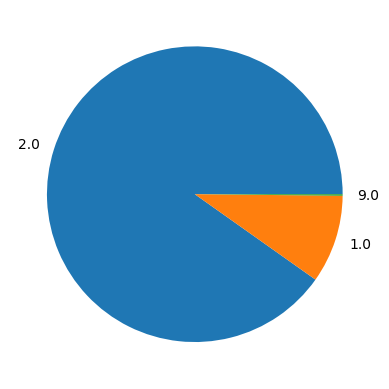

In [16]:
da["HIQ210"].value_counts().plot(kind = "pie") #pie graph
plt.show()

# Studying Real Valued Numberes

In [17]:
wt = da['BMXWT']

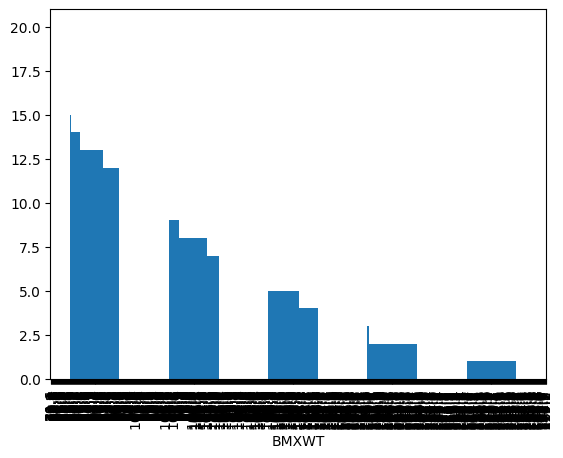

In [18]:
wt.value_counts().plot(kind = 'bar') #this does not work!!! Every one has his own weight so Caculating frequency for such data `in such a way` is useless. 
plt.show()

# Custom matplotlib Histogram

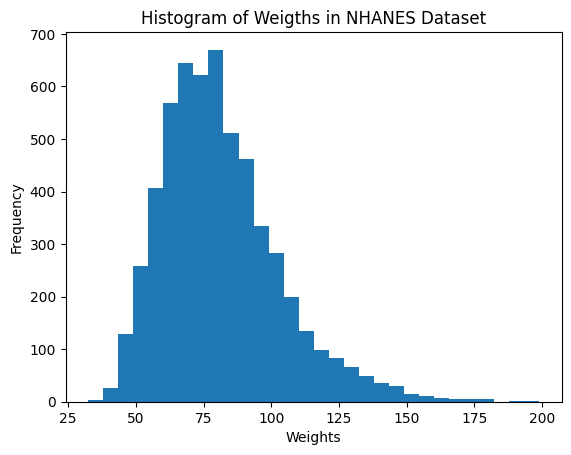

In [19]:
plt.hist(wt,bins = 30) #bins are like room.So divide them in n rooms and then calculate frequency!!!
plt.ylabel("Frequency")
plt.xlabel("Weights")
plt.title("Histogram of Weigths in NHANES Dataset")
plt.show()

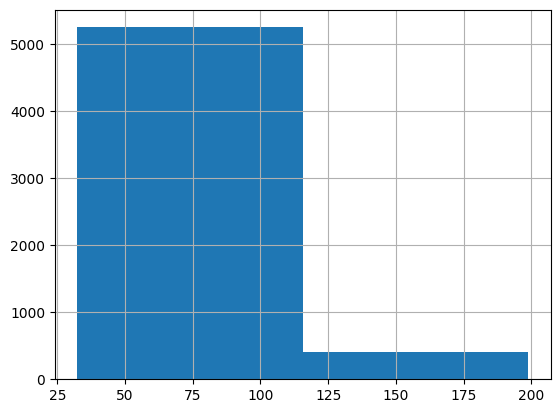

In [20]:
wt.hist(bins = 2)
plt.show()

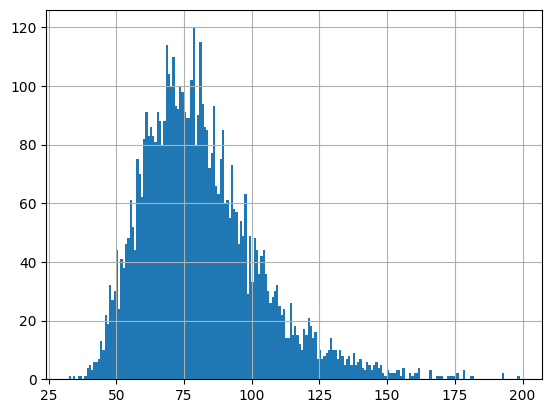

In [21]:
wt.hist(bins = 200) #making bins this huge is not a good idea
plt.show()

# Prettifying and styling Matplotlib with seaborn

In [22]:
import seaborn as sns
sns.set(color_codes=True)
sns.set_style("white")

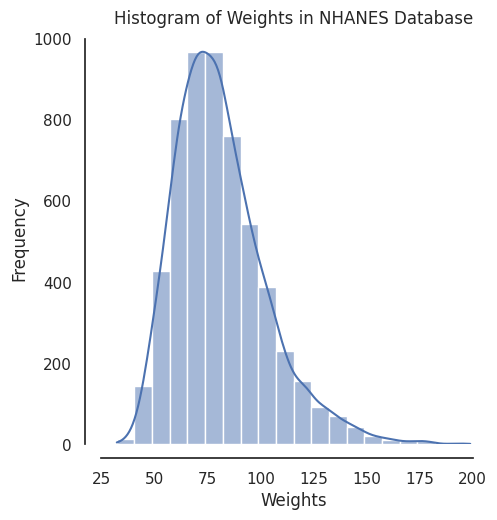

In [23]:
sns.displot(wt,bins=20,kde = True)        #`kde = True` : gives a trend line  #distplot!!! Distribution plot : another name for histogram.
plt.ylabel("Frequency")
plt.xlabel("Weights")
plt.title("Histogram of Weights in NHANES Database")
sns.despine(offset = 10 , trim = True) #move axis away
plt.show()

# Studying central tendency

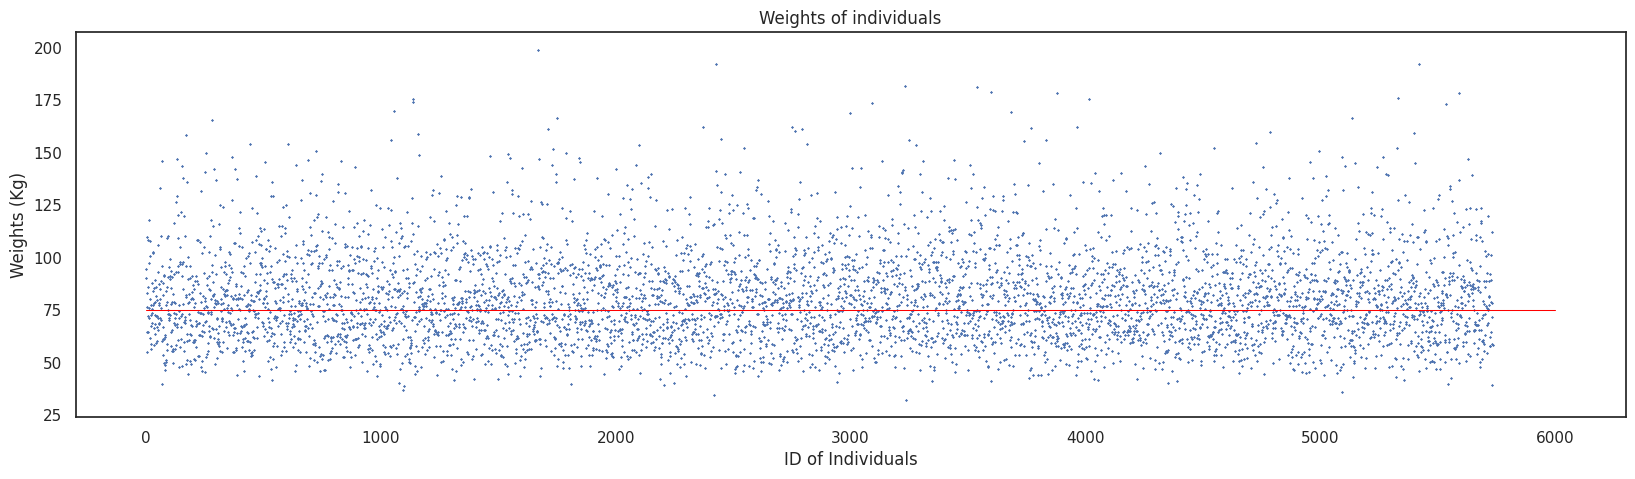

In [24]:
plt.figure(figsize = (20,5))

x = range (da['BMXWT'].size)
y = da['BMXWT']

plt.scatter(x,y ,marker = 'x' , s = 0.5 )


plt.title("Weights of individuals")
plt.xlabel("ID of Individuals")
plt.ylabel("Weights (Kg)")


#plot the eltimate line : what we estimate

p1 = (0,75) #75 is what we estimated  : can change this.
p2 = (6000,75)

x_c , y_c = zip(p1,p2)

plt.plot(x_c,y_c, color = 'red' ,linewidth = 0.75)
plt.show()


In [25]:
wt.mean() #actaul arithetetic mean is somewhere 81.34

np.float64(81.34267560889516)

##### mode (where the greater no of students lie ) is the measure of centeral tendency but it is rarely used only in certain use cases.It also not counter outliers like median.
#### Actually `mean`,`median`,`mode` all are used to measure of centeral tendency(average) !!!

# Problem with arithemetic mean

### @Outliers

##### Outliers : The values that are far away
median is `rubust` to outliers 

In [26]:
wt.min()

np.float64(32.4)

In [27]:
wt.max()

np.float64(198.9)

In [28]:
wt.median()

np.float64(78.2)

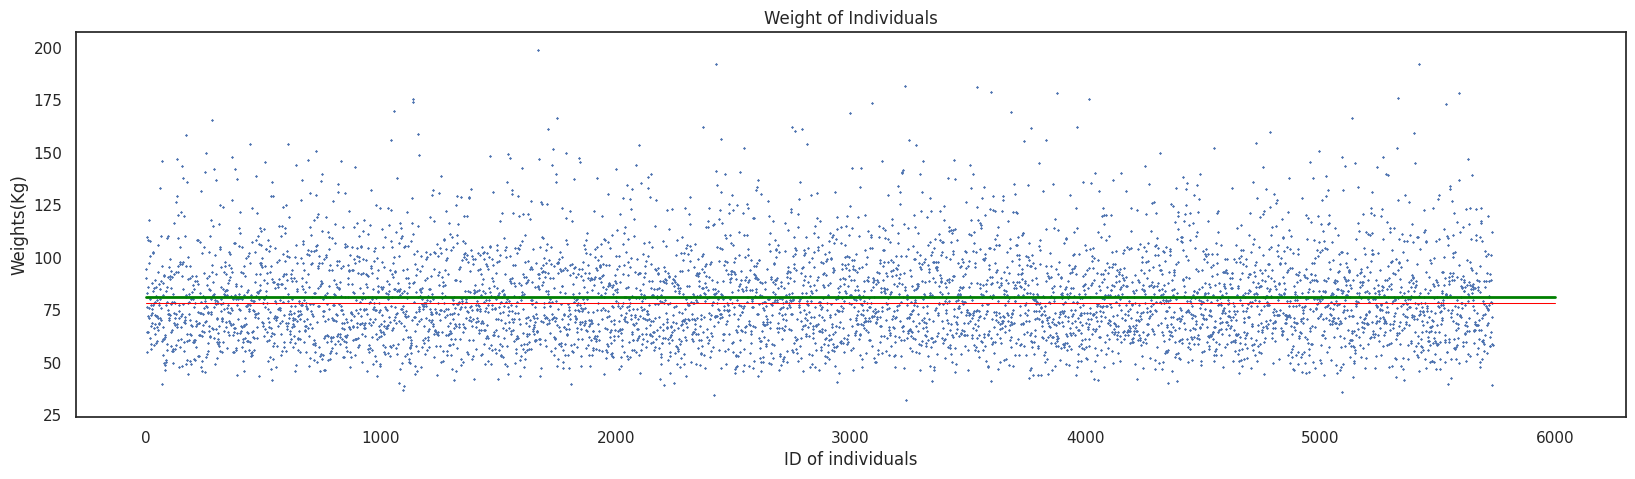

In [29]:
plt.figure(figsize = (20,5))  #x_c = xCordinates & y_c = yCordinates

x = range(da["BMXWT"].size)
y = da['BMXWT']

plt.scatter (x,y ,marker = 'x' , s = 0.5)

plt.title("Weight of Individuals")
plt.xlabel("ID of individuals")
plt.ylabel("Weights(Kg)")

#plot the estimate line.Using Median
x_c , y_c = [0,6000] ,[wt.median(),wt.median()]
plt.plot(x_c,y_c , color = 'red' , linewidth = 0.75)

#plot the estimate line. Using Mean
x_c,y_c = ([0,6000]) , [wt.mean(),wt.mean()]
plt.plot(x_c,y_c , color = "green" , linewidth = 2)

plt.show()

# Quartiles and Boxplot

` Quartiles`  = dividing the data to 4 parts
` Qunatiels  ` = Q1,Q2,Q3,Q4

In [30]:
import statistics

In [31]:
statistics.quantiles( wt, n =4 )

[43.7, 50.8, 50.1]

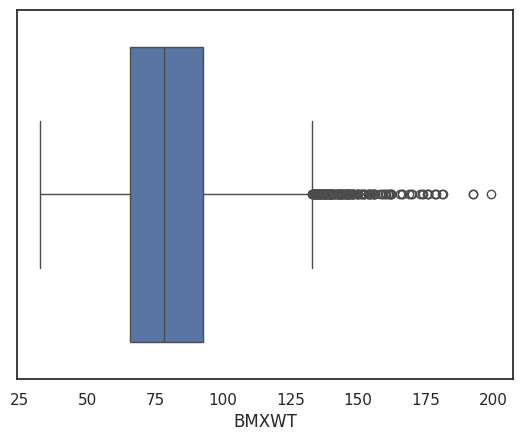

In [32]:
ax = sns.boxplot(x = wt) #these last circles are the outliers...

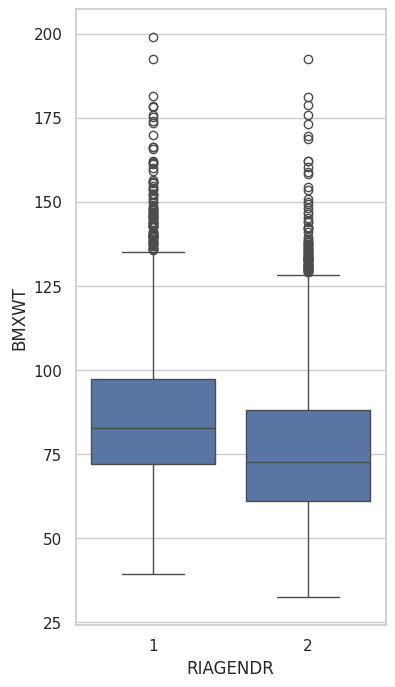

In [33]:
plt.figure(figsize = (4,8))
sns.set_style("whitegrid")
# Weigths : 1 is male : 2 is female
ax = sns.boxplot( x = "RIAGENDR",  y = "BMXWT",  data = da) # palette = "Set3"

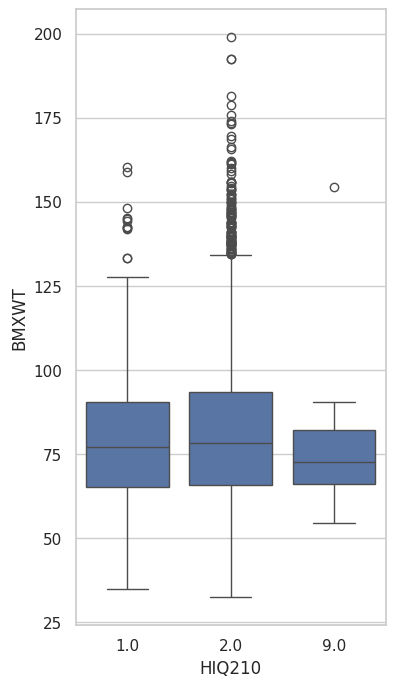

In [34]:
plt.figure(figsize = (4,8))
sns.set_style("whitegrid")
#Health insurance : 1 = insure : 2 = not insured : 3  = Not Known
ax = sns.boxplot( x = "HIQ210",  y = "BMXWT",  data = da) # palette = "Set3"